# gust_factor 说明

根据历史站点「10 m 平均风速预报 + 阵风观测」估计阵风系数，并用 10 m U/V 格点生成订正后的阵风预报场。

$$
\mathrm{param}=\frac{\sum_i \mathrm{obs}_i\cdot\mathrm{fcst}_i}{\sum_i \mathrm{fcst}_i^{2}}
$$

订正：

$$
g_0=\mathrm{ws}\cdot\mathrm{param},\quad
g_1=a\cdot g_0+b,\quad
\mathrm{gust}=\max\bigl(\mathrm{ws},\;\mathrm{safe}(g_1)\bigr)
$$

其中 \(\mathrm{ws}=\sqrt{u^{2}+v^{2}}\)；\(\mathrm{safe}\) 将负值或 \(>100\) 回退为 \(g_0\)。

本文与 [docs/gust_factor_程序说明.md](../docs/gust_factor_程序说明.md) 结构、内容一致。


## 1. 算法说明

| 项目 | 内容 |
|------|------|
| 算法代号 | `gust_factor` |
| 功能 | ① 统计阵风系数 JSON；② 用系数将平均风场订正为阵风格点 |
| 输入 | 站点 CSV（`fcst_wind`/`obs_gust`）；格点 U/V NC |
| 输出 | `gust_factor.json`；订正阵风 NC；可选对比 PNG |
| 依赖 | `numpy` / `pandas` / `meteva_base`（格点读写）；可选 `matplotlib` |

本包**无独立 runner**；调度与算法核同在 `src/gust_factor.py`。


## 2. 算法原理

### 2.1 系数估计（按预报时效）

对同一时效 \(h\) 的样本集 \(\{(\mathrm{fcst}_i,\mathrm{obs}_i)\}\)：

1. **线性阵风系数**（过原点最小二乘）  
   \(\mathrm{param}=\sum(\mathrm{obs}\cdot\mathrm{fcst})/\sum\mathrm{fcst}^{2}\)，使 \(\mathrm{obs}\approx\mathrm{param}\cdot\mathrm{fcst}\)。

2. **分位数匹配**  
   令 \(x_i=\mathrm{fcst}_i\cdot\mathrm{param}\)，在固定百分位序列  
   \(P=\{10,15,\ldots,95,99\}\) 上取预报分位与观测分位，再拟合  
   \(y=ax+b\)，得到斜截距 \(a,b\)，用于校正分位结构偏差。

### 2.2 实时订正

1. 由 U/V 计算平均风速 \(\mathrm{ws}\)。  
2. \(g_0=\mathrm{ws}\cdot\mathrm{param}\)，\(g_1=a\cdot g_0+b\)。  
3. 若 \(g_1<0\) 或 \(g_1>100\)，回退 \(g_0\)。  
4. 强制 \(\mathrm{gust}\ge\mathrm{ws}\)（阵风不低于平均风）。


## 3. 算法原理实现方法

| 层级 | 路径 | 说明 |
|------|------|------|
| 算法核 + 调度 | `src/gust_factor.py` | 两个 Plugin + `process` |
| 配置 | `src/utils/util_env.py` | 读 `resource/gust_factor.ini` |
| CLI | `cli/__main__.py` | argparse → `process` |

**系数计算（`GustFactorCalculatorPlugin`）**

1. 校验列名，去 NaN，样本量 ≥ 100。  
2. 按 `dtime` 过滤各时效，算 `param`。  
3. `_calc_percent_value` → `_least_squares_method` 得 `a,b`。  
4. 可选 `json.dump` 写出。

**订正（`GustCorrectWithFactorPlugin`）**

1. `meteva_base.read_griddata_from_nc` 读 U/V。  
2. 取水平二维切片算 `ws`，加载 JSON 系数。  
3. 约束后 `meb.grid_data` 组装场，`write_griddata_to_nc` 写出。

**`process` 模式**

| mode | 行为 |
|------|------|
| `calc` | 仅算系数 |
| `correct` | 仅订正（须已有 JSON） |
| `all` | 先算系数再订正（默认） |


In [ ]:
from pathlib import Path
import sys

root = Path("..").resolve()
sys.path[:0] = [str(root), str(root / "src")]

from utils.util_env import get_resolved_paths, get_run_params, get_repo_root

print("仓库根:", get_repo_root())
print("路径:", get_resolved_paths())
print("运行参数:", get_run_params())


## 4. 算法应用

典型场景：

1. **离线标定**：用一段时间历史「模式 10 m 风预报 + 站阵风观测」生成分时效系数文件。  
2. **业务订正**：起报后读取当次 U/V，按对应时效加载系数，输出阵风格点供下游检验/产品。  
3. **演示复现**：本包 `resource/test_data/*.csv` + `resource/sample/*.nc` 可直接 `python -m cli` 跑通。

注意：示范 CSV 可为随机合成数据，业务使用请替换为真实样本；系数时效键须覆盖订正所用 `fore_hour`。


## 5. 算法调用

### 5.1 参数（ini / CLI）

| 参数 | ini 键 | CLI | 默认 | 含义 |
|------|--------|-----|------|------|
| `mode` | `mode` | `--mode` | `all` | `calc` / `correct` / `all` |
| 站点目录 | `station_csv_dir` | `--station-dir` | `resource/test_data` | 训练 CSV 目录 |
| `fore_hours` | `fore_hours` | `--fore-hours` | `24,48,72` | 统计时效 |
| 系数路径 | `factor_path` | `--factor` | `resource/output/gust_factor.json` | JSON |
| U/V | `u_path` / `v_path` | `--u` / `--v` | sample NC | 订正输入 |
| `fore_hour` | `fore_hour` | `--fore-hour` | `24` | 订正时效 |
| 输出 | `output_path` | `--output` | `resource/output/...nc` | 阵风 NC |
| 出图 | `make_png` 等 | `--make-png` / `--ws` / `--png` | 见 ini | 可选对比图 |

### 5.2 CLI

```bash
cd gust_factor
python -m cli --help
python -m cli
python -m cli --mode=calc --station-dir=resource/test_data
python -m cli --mode=correct --fore-hour=24
python -m cli --mode=all --fore-hours=24,48,72 --make-png=true
```

### 5.3 模块调用

```python
from gust_factor import process, GustFactorCalculatorPlugin, GustCorrectWithFactorPlugin

# 一站式
process(mode="all")

# 仅算法核
# g = GustFactorCalculatorPlugin()(station_df, fore_hours=(24, 48, 72), save_path="a.json")
# out = GustCorrectWithFactorPlugin()(u_da, v_da, 24, "a.json")
```

### 5.4 直跑

```bash
python src/gust_factor.py
```

格点读写一律优先 `meteva_base.read_griddata_from_nc` / `write_griddata_to_nc`。


In [ ]:
# 演示：用 resource/test_data 计算阵风系数（与 docs 模块调用一致）
from pathlib import Path
import sys

root = Path("..").resolve()
sys.path[:0] = [str(root), str(root / "src")]

from gust_factor import GustFactorCalculatorPlugin, load_station_csv_dir

csv_dir = root / "resource" / "test_data"
out_json = root / "resource" / "output" / "gust_factor_nb_demo.json"
df = load_station_csv_dir(str(csv_dir))
print("样本数:", len(df), "列:", list(df.columns))

g = GustFactorCalculatorPlugin().process(
    df, fore_hours=(24, 48, 72), save_path=str(out_json)
)
print("系数:", g)
print("已写出:", out_json)


In [ ]:
# 演示：读 sample U/V，订正阵风并写出 NC（meteva_base I/O）
from pathlib import Path
import sys
import numpy as np

root = Path("..").resolve()
sys.path[:0] = [str(root), str(root / "src")]

from gust_factor import (
    GustCorrectWithFactorPlugin,
    read_grid_nc,
    write_grid_nc,
)

sample = root / "resource" / "sample"
factor = root / "resource" / "output" / "gust_factor_nb_demo.json"
if not factor.is_file():
    factor = root / "resource" / "output" / "gust_factor.json"

u_da = read_grid_nc(str(sample / "UTC_20260505000000_WIU10_024.nc"))
v_da = read_grid_nc(str(sample / "UTC_20260505000000_WIV10_024.nc"))
g_da = GustCorrectWithFactorPlugin().process(u_da, v_da, 24, str(factor))

out_nc = root / "resource" / "output" / "gust_nb_demo.nc"
write_grid_nc(g_da, str(out_nc))
arr = np.asarray(g_da.values)
print("阵风场 shape:", arr.shape, "min/max:", float(np.nanmin(arr)), float(np.nanmax(arr)))
print("已写出:", out_nc)


=-------------------------------------------->>>> True True
############################################################
start calculate gust factor
############################################################
**********start calculate gust factor in fcst hour[24]
per list: [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 99]
fore per: [7.94, 8.99, 10.1, 11.05, 11.78, 12.77, 13.65, 14.55, 15.59, 16.52, 17.44, 18.4, 19.35, 20.32, 21.22, 22.05, 23.07, 23.98, 24.68]
obs per: [7.71, 8.66, 9.44, 10.35, 11.27, 12.19, 13.11, 13.98, 14.93, 15.74, 16.64, 17.47, 18.6, 19.77, 21.23, 22.9, 24.8, 27.55, 31.01]
gust factor for [24h] is: {'param': 1.2423082807489945, 'a': 1.2184437579315341, 'b': -3.398562201151627}
**********start calculate gust factor in fcst hour[48]
per list: [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 99]
fore per: [7.95, 8.88, 9.96, 10.88, 11.79, 12.81, 13.88, 14.62, 15.59, 16.56, 17.38, 18.25, 19.22, 20.26, 21.17, 22.05, 23.

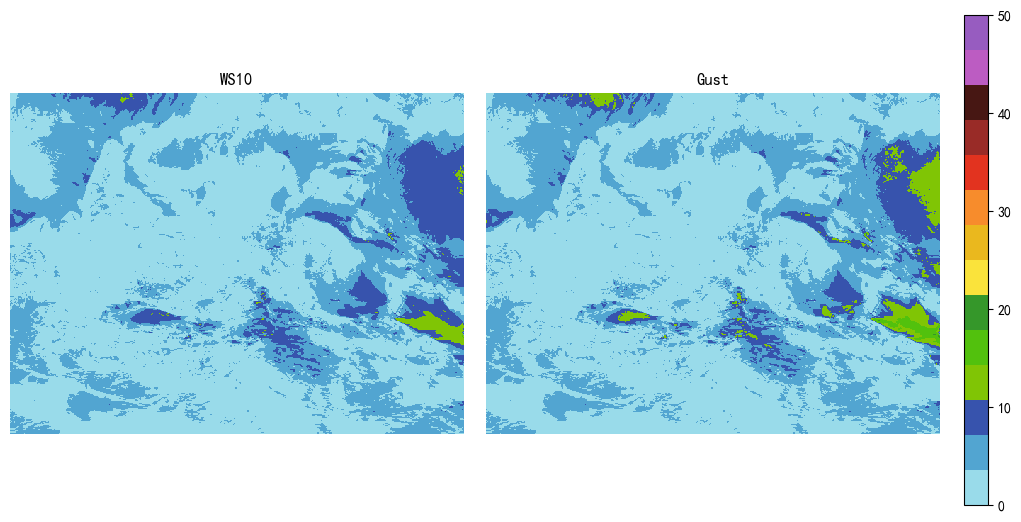

对比图片已保存至：D:\Work\NIMM_pip_repos_tmp\gust_factor\resource\output\WS_and_GUST.png
{'mode': 'all', 'repo_root': 'D:\\Work\\NIMM_pip_repos_tmp\\gust_factor', 'gust_factor': {'24': {'param': 1.2423082807489945, 'a': 1.2184437579315341, 'b': -3.398562201151627}, '48': {'param': 1.2518680373168483, 'a': 1.2177235302912122, 'b': -3.3464315315938933}, '72': {'param': 1.2529125987274072, 'a': 1.2347064987784628, 'b': -3.702085167535664}}, 'factor_path': 'D:\\Work\\NIMM_pip_repos_tmp\\gust_factor\\resource\\output\\gust_factor.json', 'output_path': 'D:\\Work\\NIMM_pip_repos_tmp\\gust_factor\\resource\\output\\UTC_20260505000000_10FG_024.nc', 'fore_hour': 24, 'png_path': 'D:\\Work\\NIMM_pip_repos_tmp\\gust_factor\\resource\\output\\WS_and_GUST.png'}


In [2]:
# 一站式入口（与 CLI / docs 5.3 一致；默认读 ini，可按需改 mode）
from pathlib import Path
import sys

root = Path("..").resolve()
sys.path[:0] = [str(root), str(root / "src")]

from gust_factor import process

# 仅算系数示例；完整链路可改为 mode="all"
result = process(mode="all", make_png=True, show_png=True)
print(result)
